# Analyse following simultaneously to find any pattern (in progress):  
1. Find synchronisation core


In [1]:
%reload_ext autoreload
%autoreload 2


from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc

from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import pandas as pd
import numpy as np


#### Create objects


In [2]:
reader=DataRead()
analyse=AnalysisFunc()

#### Load data

In [3]:
df_itr=reader.data_read_bz2('itr_test.bz2')
df_loc = reader.data_read_bz2('loc_test.bz2')
df_nc = reader.data_read_bz2('nc_test.bz2')

#### Running analysis to get itration for analysis

In [4]:
analyse.compute_param(df_itr,0.05)

Number of transitions / 100 iteration [0, 13]
Number of transition [1, 2, 4, 5, 6, 7, 8, 9]
Number of transition with more than one transition or a fall back [2, 4, 5, 7]


{'tran_per': [0, 13],
 'trans': [71.5,
  102.9,
  106.75,
  35.0,
  57.550000000000004,
  37.95,
  46.6,
  69.15,
  40.150000000000006,
  31.450000000000003,
  32.45,
  32.45,
  172.15],
 'sync': [282.65000000000003, 150.45, 1142.05, 93.92500000000001]}

#### Checking by plotting above iterations to find suitable one

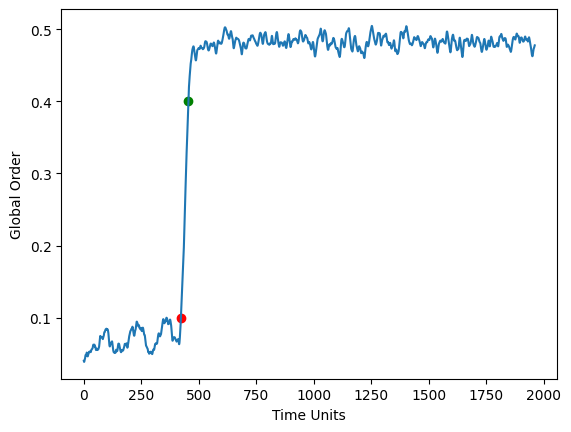

In [5]:
#iteration 1,5,6,8,9
n=8
analyse.plot_global_synchrony(df_itr[n],0.05)

#### Let's try to see if there really exist the pattern  
Strategy:
1) If we can use ML technique to recognize pattern
2) Can use only single transition data which is in server data

Let's try some ML

In [12]:
df=df_nc.loc[8]
df.loc[4000,22]

nan

9


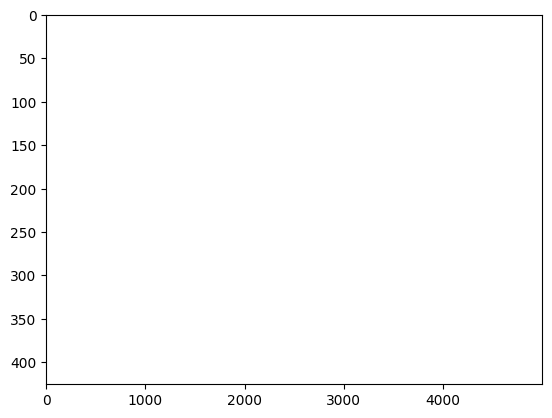

In [8]:
# Kmeans clustering
nc_arr=df_nc.loc[n].values
nc_arr[nc_arr==0]=np.nan
mc=analyse.compute_main_cluster(df_nc.loc[8])
print(mc)
nc=nc_arr
nc_arr[nc_arr!=mc]=np.nan

plt.imshow(nc.T,aspect='auto')
# plt.figure(num=2)
# plt.imshow(nc_arr.T,aspect='auto')

In [26]:
df_nc.loc[8]

,0,1,2,3,4,5,6,7,8,9,...,416,417,418,419,420,421,422,423,424,425
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
